# k-Means Clustering

## Overview

k-means partitions n observations into k clusters by iteratively assigning each observation to its nearest centroid and updating centroids to the cluster mean. It minimises within-cluster sum of squares (WCSS):

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Assumptions and limitations:**
- Clusters are convex (roughly spherical) and similar in size
- All features contribute equally — scaling is essential
- k must be specified in advance
- Sensitive to outliers (which pull centroids)
- Results vary with random initialisation — always run multiple starts

**Choosing k:**

| Method | Idea | Use when |
|---|---|---|
| **Elbow method** | Plot WCSS vs. k; find the "elbow" | Quick first pass |
| **Silhouette score** | Mean separation between clusters | More principled; interpretable |
| **Gap statistic** | Compare WCSS to null reference distribution | Small n; gold standard |
| **Domain knowledge** | Pre-specified number of groups | Known structure exists |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(cluster)       # silhouette(), clusGap()
library(factoextra)    # fviz_cluster(), fviz_silhouette(), fviz_gap_stat()
library(patchwork)

set.seed(42)

# ── Simulate: 4 ecological site types ────────────────────────────────────────
n_per <- 80
clust_data <- bind_rows(
  tibble(nitrate=rnorm(n_per,2,0.6), water_qual=rnorm(n_per,8,0.8),
         phosphorus=rnorm(n_per,0.3,0.1), turbidity=rnorm(n_per,3,1),
         true_group="reference"),
  tibble(nitrate=rnorm(n_per,4,0.8), water_qual=rnorm(n_per,6,0.9),
         phosphorus=rnorm(n_per,0.6,0.15), turbidity=rnorm(n_per,6,1.5),
         true_group="restored"),
  tibble(nitrate=rnorm(n_per,7,1.0), water_qual=rnorm(n_per,4,1.0),
         phosphorus=rnorm(n_per,1.2,0.25), turbidity=rnorm(n_per,12,2),
         true_group="degraded"),
  tibble(nitrate=rnorm(n_per,9,1.2), water_qual=rnorm(n_per,2.5,0.8),
         phosphorus=rnorm(n_per,2.0,0.4), turbidity=rnorm(n_per,20,3),
         true_group="heavily_degraded")
)

# ── Scale features: MANDATORY for k-means ────────────────────────────────────
X_scaled <- clust_data %>%
  select(nitrate, water_qual, phosphorus, turbidity) %>%
  scale()

cat(sprintf("n=%d | %d features\n", nrow(clust_data), ncol(X_scaled)))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message:
"package 'patchwork' was bui

n=320 | 4 features


---

## Choosing k

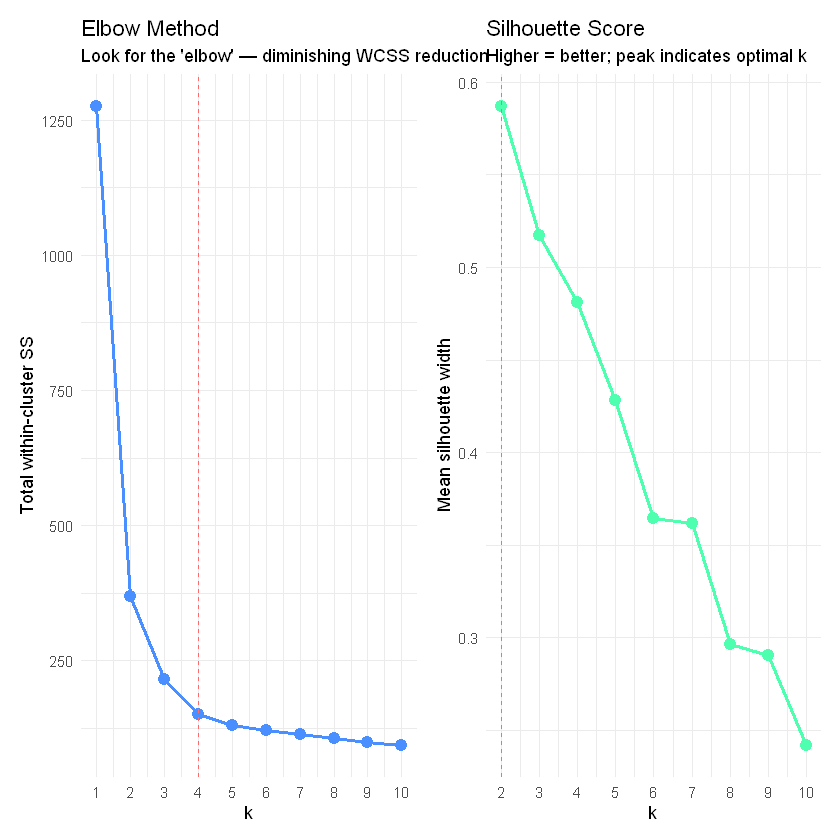

In [2]:
# ── Elbow method: WCSS vs. k ──────────────────────────────────────────────────
wcss <- map_dbl(1:10, function(k) {
  kmeans(X_scaled, centers=k, nstart=25, iter.max=100)$tot.withinss
})

p_elbow <- tibble(k=1:10, wcss=wcss) %>%
  ggplot(aes(x=k, y=wcss)) +
  geom_line(color="#4a8fff", linewidth=1) +
  geom_point(size=3, color="#4a8fff") +
  geom_vline(xintercept=4, linetype="dashed", color="#ff6b6b") +
  scale_x_continuous(breaks=1:10) +
  labs(title="Elbow Method",
       subtitle="Look for the 'elbow' — diminishing WCSS reduction",
       x="k", y="Total within-cluster SS") +
  theme_minimal()

# ── Silhouette scores: mean separation quality ────────────────────────────────
sil_scores <- map_dbl(2:10, function(k) {
  km  <- kmeans(X_scaled, centers=k, nstart=25, iter.max=100)
  sil <- cluster::silhouette(km$cluster, dist(X_scaled))
  mean(sil[,3])   # mean silhouette width
})

p_sil <- tibble(k=2:10, silhouette=sil_scores) %>%
  ggplot(aes(x=k, y=silhouette)) +
  geom_line(color="#4fffb0", linewidth=1) +
  geom_point(size=3, color="#4fffb0") +
  geom_vline(xintercept=which.max(sil_scores)+1, linetype="dashed", color="#ff6b6b") +
  scale_x_continuous(breaks=2:10) +
  labs(title="Silhouette Score",
       subtitle="Higher = better; peak indicates optimal k",
       x="k", y="Mean silhouette width") +
  theme_minimal()

(p_elbow | p_sil)

---

## Fit Final k-Means Model

Within-cluster SS: 150.2 (11.8% of total)

Cluster sizes:
[1] 79 81 77 83


          true_group
km_cluster degraded heavily_degraded reference restored
         1       79                0         0        0
         2        1               80         0        0
         3        0                0         0       77
         4        0                0        80        3

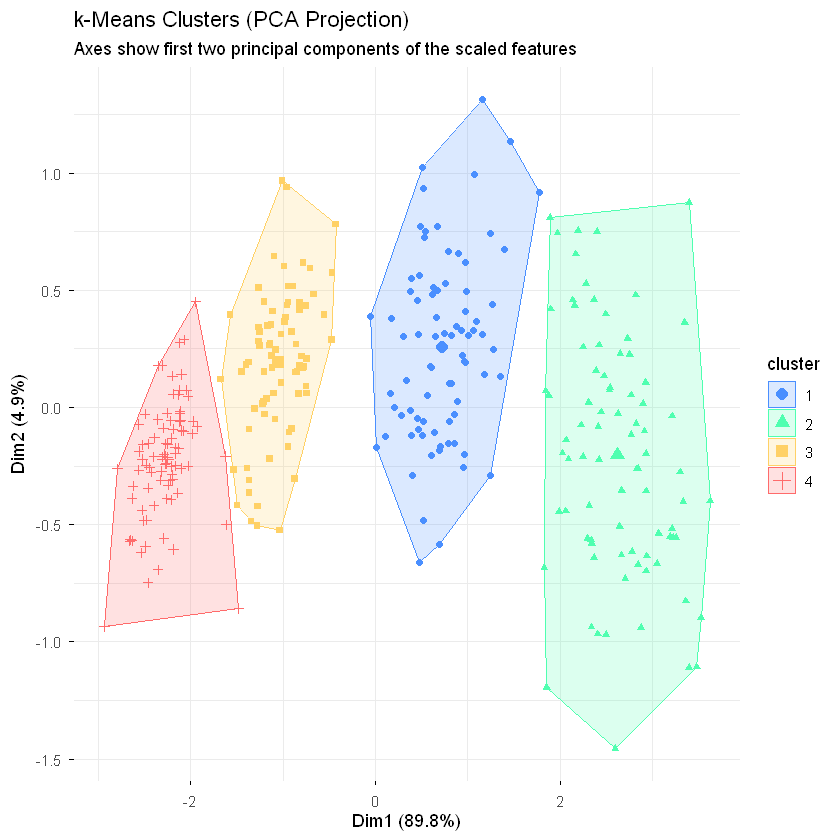

In [3]:
# nstart=25: run 25 random initialisations; keep the best
# iter.max=100: max iterations per run
km_fit <- kmeans(X_scaled, centers=4, nstart=25, iter.max=100)

cat(sprintf("Within-cluster SS: %.1f (%.1f%% of total)\n",
            km_fit$tot.withinss,
            km_fit$tot.withinss / km_fit$totss * 100))
cat("\nCluster sizes:\n")
print(km_fit$size)

# Assign clusters to data
results <- clust_data %>%
  mutate(cluster = factor(km_fit$cluster))

# ── Cluster plot (PCA projection) ─────────────────────────────────────────────
factoextra::fviz_cluster(
  km_fit, data=X_scaled,
  palette       = c("#4a8fff","#4fffb0","#ffd166","#ff6b6b"),
  geom          = "point",
  ellipse.type  = "convex",
  ggtheme       = theme_minimal()
) +
  labs(title="k-Means Clusters (PCA Projection)",
       subtitle="Axes show first two principal components of the scaled features")

# ── Agreement with true groups ────────────────────────────────────────────────
table(km_cluster=results$cluster, true_group=results$true_group)

---

## Per-Observation Silhouette Plot

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


  cluster size ave.sil.width
1       1   79          0.48
2       2   81          0.41
3       3   77          0.45
4       4   83          0.57
Observations with negative silhouette: 3 (0.9%)


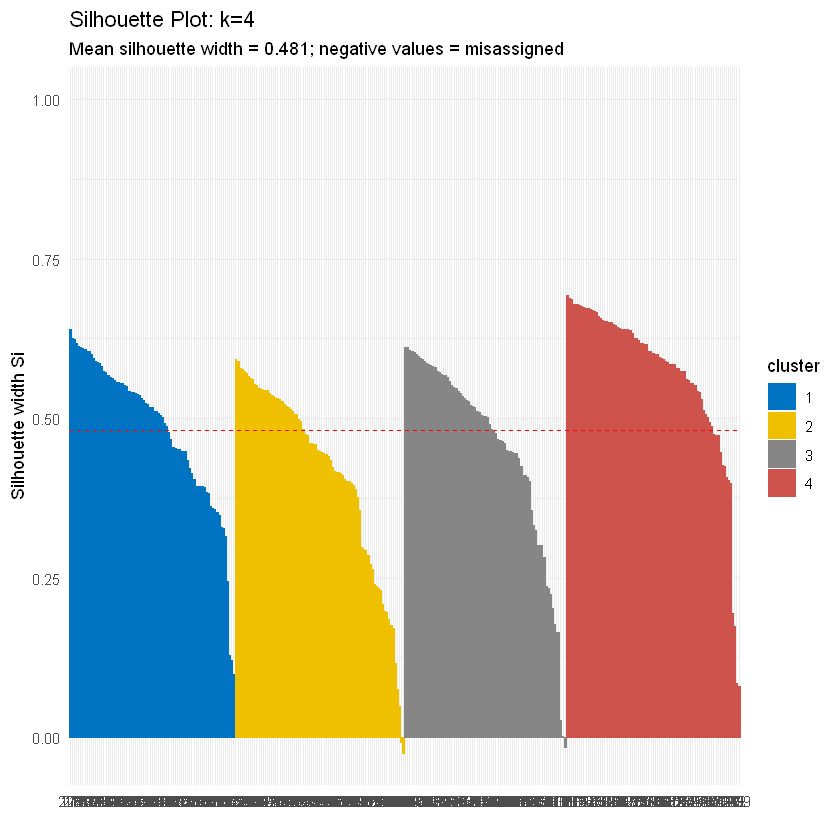

In [4]:
sil_obj <- cluster::silhouette(km_fit$cluster, dist(X_scaled))

factoextra::fviz_silhouette(sil_obj, palette="jco") +
  labs(title="Silhouette Plot: k=4",
       subtitle=sprintf("Mean silhouette width = %.3f; negative values = misassigned",
                        mean(sil_obj[,3]))) +
  theme_minimal()

# Interpretation:
# Width close to 1: observation well-matched to its cluster
# Width near 0: observation on the boundary between two clusters
# Negative width: observation may be better placed in neighbouring cluster

cat(sprintf("Observations with negative silhouette: %d (%.1f%%)\n",
            sum(sil_obj[,3] < 0),
            mean(sil_obj[,3] < 0) * 100))

---

## Common Pitfalls

**1. Not scaling features before k-means**  
k-means uses Euclidean distance. A feature measured in mg/L with range 0–50 dominates a feature measured in km with range 0–2. Always standardise all features to zero mean and unit variance before clustering. The interpretation of "distance" is meaningless without scaling.

**2. Running k-means once with a single random initialisation**  
k-means is sensitive to random starting positions and can converge to a local minimum. Always set `nstart ≥ 25` to run multiple initialisations and retain the best solution (lowest WCSS). The default `nstart=1` in base R is insufficient.

**3. Using the elbow method as the sole criterion for choosing k**  
Elbows are often ambiguous — the "bend" is subjective and sometimes absent entirely. Always combine the elbow method with at least one other criterion (silhouette score, gap statistic, or domain knowledge). The silhouette score has a clear maximum and is more objective.

**4. Applying k-means to non-spherical or differently-sized clusters**  
k-means assumes clusters are convex and roughly equal in size. Elongated, irregularly shaped, or greatly size-imbalanced clusters will be partitioned incorrectly. Use DBSCAN for irregular shapes or GMMs for variable sizes — see `dbscan.ipynb` and `gaussian_mixture_models.ipynb`.

**5. Treating cluster labels as stable across runs**  
Cluster labels (1, 2, 3…) are arbitrary and change between runs. Cluster 1 in one run may correspond to cluster 3 in another. Never compare cluster numbers across separate `kmeans()` calls without first aligning clusters by their centroids or composition.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*